# Core Count Summary Plots

This notebook scans a refined runs folder, reads every `summary.json`, and builds one dual-axis plot per TT-LoRA type for each dataset.

Design choices:
- x-axis is **core count** (the sweep variable in these experiments)
- left y-axis is **trainable parameter count**
- right y-axis is **best validation accuracy** for classification or **best validation perplexity** for generation
- learning rate is **ignored** during plotting
- if multiple learning rates exist for the same dataset, TT-LoRA type, and core count, the notebook keeps the **best metric across learning rates**
  - classification: highest validation accuracy
  - generation: lowest validation perplexity

Each dataset gets one figure with two subplots:
- contraction
- reconstruction


In [53]:
from __future__ import annotations

import math
import json
import re
from pathlib import Path
from typing import Any

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        'This notebook needs matplotlib in the active kernel. Install it with something like `pip install matplotlib seaborn pandas`.'
    ) from exc
from matplotlib.ticker import FuncFormatter

import pandas as pd

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        'This notebook uses seaborn for plotting. Install it with something like `pip install seaborn` in the active kernel.'
    ) from exc

sns.set_theme(style='whitegrid', context='talk', palette='deep')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

# Update this if you want to point at a different refined folder.
RUNS_ROOT = Path('/home/pkunwar/characterize_ttlora/phases/ttlora_core_count_study/runs_refined').resolve()

# Plot tuning.
GRID_COLUMNS = 2
PANEL_WIDTH = 11
PANEL_HEIGHT = 7
ACCURACY_YMIN = 50
ACCURACY_YMAX = 100

# Figure export.
SAVE_FIGURE = True
FIGURE_OUTPUT_PATH = (RUNS_ROOT.parent / 'analysis_outputs' / 'core_count_summary_grid.png').resolve()

RUNS_ROOT


PosixPath('/home/pkunwar/characterize_ttlora/phases/ttlora_core_count_study/runs_refined')

In [54]:
def _coerce_scalar(value: Any) -> Any:
    if value is None or isinstance(value, (bool, int, float, list, dict)):
        return value
    text = str(value).strip()
    if text == '' or text.lower() in {'none', 'null', 'nan'}:
        return None
    try:
        if re.fullmatch(r'-?\d+', text):
            return int(text)
        return float(text)
    except ValueError:
        return value


def infer_total_cores(summary: dict[str, Any], run_name: str) -> int | None:
    ttlora_shape = summary.get('ttlora_shape')
    if isinstance(ttlora_shape, list) and ttlora_shape:
        return len(ttlora_shape)

    weight_configs = summary.get('ttlora_weight_configs')
    if isinstance(weight_configs, list) and weight_configs:
        tt_shape = weight_configs[0].get('tt_shape')
        if isinstance(tt_shape, list) and tt_shape:
            return len(tt_shape)

    match = re.search(r'cores(\d+)', run_name)
    return int(match.group(1)) if match else None


def load_summary_frame(runs_root: Path) -> pd.DataFrame:
    rows = []
    for summary_path in sorted(runs_root.rglob('summary.json')):
        summary = json.loads(summary_path.read_text())
        run_dir = summary_path.parent
        run_name = run_dir.name
        group_dir = run_dir.parent.name

        row = {key: _coerce_scalar(value) for key, value in summary.items()}
        row['summary_path'] = str(summary_path)
        row['run_dir'] = str(run_dir)
        row['run_name'] = run_name
        row['group_dir'] = group_dir
        row['total_cores'] = infer_total_cores(summary, run_name)
        row['dataset_name'] = row.get('dataset_name') or group_dir.split('_')[0]
        row['ttlora_variant'] = row.get('ttlora_variant') or group_dir.split('_', 1)[-1]

        task_type = str(row.get('task_type', '')).lower()
        if task_type == 'generation':
            row['metric_name'] = 'best_validation_perplexity'
            row['metric_value'] = row.get('best_validation_perplexity')
            row['metric_mode'] = 'min'
        else:
            row['metric_name'] = 'best_validation_accuracy'
            accuracy = row.get('best_validation_accuracy')
            row['metric_value'] = 100.0 * accuracy if accuracy is not None else None
            row['metric_mode'] = 'max'

        rows.append(row)

    if not rows:
        raise FileNotFoundError(f'No summary.json files found under {runs_root}')

    df = pd.DataFrame(rows)
    sort_cols = [col for col in ['dataset_name', 'ttlora_variant', 'total_cores', 'learning_rate'] if col in df.columns]
    return df.sort_values(sort_cols).reset_index(drop=True)


def collapse_learning_rates(group_df: pd.DataFrame) -> pd.DataFrame:
    if group_df.empty:
        return group_df.copy()

    metric_mode = str(group_df['metric_mode'].dropna().iloc[0]) if 'metric_mode' in group_df.columns and not group_df['metric_mode'].dropna().empty else 'max'
    ascending = metric_mode == 'min'

    sortable = group_df.copy()
    sortable['metric_value_sort'] = sortable['metric_value']
    sortable = sortable.dropna(subset=['total_cores'])

    if sortable['metric_value_sort'].notna().any():
        sortable = sortable.sort_values(['total_cores', 'metric_value_sort'], ascending=[True, ascending])
    else:
        sortable = sortable.sort_values(['total_cores'])

    collapsed = sortable.groupby('total_cores', as_index=False).first()
    collapsed = collapsed.sort_values('total_cores').reset_index(drop=True)
    return collapsed


def metric_axis_label(task_type: str) -> str:
    if task_type == 'generation':
        return 'Best Validation Perplexity (lower is better)'
    return 'Best Validation Accuracy (%) (higher is better)'


def parameter_formatter_k(value: float, _: int) -> str:
    return f'{value / 1000:.0f}K'


def plot_dataset(ax: plt.Axes, summary_df: pd.DataFrame, dataset_name: str) -> None:
    dataset_df = summary_df.loc[summary_df['dataset_name'] == dataset_name].copy()
    if dataset_df.empty:
        ax.axis('off')
        return

    task_type = str(dataset_df['task_type'].dropna().iloc[0]).lower() if 'task_type' in dataset_df.columns and not dataset_df['task_type'].dropna().empty else ''
    metric_label = metric_axis_label(task_type)
    variant_styles = {
        'contraction': {
            'param_color': '#1f77b4',
            'metric_color': '#d62728',
            'linestyle': '-',
        },
        'reconstruction': {
            'param_color': '#17becf',
            'metric_color': '#ff7f0e',
            'linestyle': '--',
        },
    }

    metric_ax = ax.twinx()

    all_core_counts = sorted(dataset_df['total_cores'].dropna().unique().tolist())
    if all_core_counts:
        ax.set_xticks(all_core_counts)
    ax.set_xlabel('Core Count')
    ax.set_ylabel('Trainable Parameters (K)')
    metric_ax.set_ylabel(metric_label)
    ax.set_title(f'{dataset_name.upper()} | Contraction and Reconstruction', pad=14, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.22)
    ax.margins(x=0.08)
    metric_ax.margins(x=0.08)
    ax.yaxis.set_major_formatter(FuncFormatter(parameter_formatter_k))

    if task_type != 'generation':
        metric_ax.set_ylim(ACCURACY_YMIN, ACCURACY_YMAX)

    legend_lines = []
    legend_labels = []

    for variant in ['contraction', 'reconstruction']:
        variant_df = dataset_df.loc[dataset_df['ttlora_variant'] == variant].copy()
        if variant_df.empty:
            continue

        collapsed = collapse_learning_rates(variant_df)
        param_df = collapsed.dropna(subset=['total_cores', 'trainable_parameters']).copy()
        metric_df = collapsed.dropna(subset=['total_cores', 'metric_value']).copy()
        style = variant_styles[variant]

        if not param_df.empty:
            (param_line,) = ax.plot(
                param_df['total_cores'],
                param_df['trainable_parameters'],
                marker='o',
                linewidth=2.8,
                markersize=9,
                linestyle=style['linestyle'],
                color=style['param_color'],
                label=f'{variant.title()} Parameters',
            )
            legend_lines.append(param_line)
            legend_labels.append(param_line.get_label())

        if not metric_df.empty:
            (metric_line,) = metric_ax.plot(
                metric_df['total_cores'],
                metric_df['metric_value'],
                marker='s',
                linewidth=3.2,
                markersize=7,
                linestyle=style['linestyle'],
                color=style['metric_color'],
                label=f'{variant.title()} Metric',
            )
            legend_lines.append(metric_line)
            legend_labels.append(metric_line.get_label())

    ax.tick_params(axis='y', labelcolor='#1f4e79')
    metric_ax.tick_params(axis='y', labelcolor='#8c2d04')

    if legend_lines:
        dedup_lines = []
        dedup_labels = []
        for line, label in zip(legend_lines, legend_labels):
            if label in dedup_labels:
                continue
            dedup_lines.append(line)
            dedup_labels.append(label)
        ax.legend(dedup_lines, dedup_labels, loc='upper center', ncol=2, frameon=True)


def plot_dataset_grid(summary_df: pd.DataFrame, save_figure: bool = False, figure_output_path: Path | None = None) -> None:
    dataset_names = sorted(summary_df['dataset_name'].dropna().unique().tolist())
    if not dataset_names:
        raise ValueError('No datasets found to plot.')

    ncols = GRID_COLUMNS
    nrows = math.ceil(len(dataset_names) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(PANEL_WIDTH * ncols, PANEL_HEIGHT * nrows),
        constrained_layout=True,
    )

    if not isinstance(axes, (list, tuple)):
        axes_flat = axes.ravel() if hasattr(axes, 'ravel') else [axes]
    else:
        axes_flat = axes

    axes_flat = list(axes_flat)
    for ax, dataset_name in zip(axes_flat, dataset_names):
        plot_dataset(ax, summary_df, dataset_name)

    for ax in axes_flat[len(dataset_names):]:
        ax.axis('off')

    if save_figure:
        if figure_output_path is None:
            raise ValueError('figure_output_path must be provided when save_figure=True')
        figure_output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(figure_output_path, dpi=300, bbox_inches='tight')
        print(f'Saved figure to {figure_output_path}')

    plt.show()


In [55]:
summary_df = load_summary_frame(RUNS_ROOT)

print(f'Loaded {len(summary_df)} summaries from {RUNS_ROOT}')
display(
    summary_df[[
        col for col in [
            'group_dir',
            'dataset_name',
            'ttlora_variant',
            'task_type',
            'total_cores',
            'learning_rate',
            'trainable_parameters',
            'best_validation_accuracy',
            'best_validation_perplexity',
        ]
        if col in summary_df.columns
    ]].head(20)
)

display(
    summary_df.groupby(['dataset_name', 'ttlora_variant', 'task_type']).size().rename('run_count').reset_index().sort_values(['dataset_name', 'ttlora_variant'])
)


Loaded 140 summaries from /home/pkunwar/characterize_ttlora/phases/ttlora_core_count_study/runs_refined


,group_dir,dataset_name,ttlora_variant,task_type,total_cores,learning_rate,trainable_parameters,best_validation_accuracy,best_validation_perplexity
0,cola_contraction,cola,contraction,NaN,2,0.0002,331776,0.858102,NaN
1,cola_contraction,cola,contraction,NaN,3,0.0020,195264,0.822627,NaN
2,cola_contraction,cola,contraction,NaN,4,0.0020,58752,0.857143,NaN
3,cola_contraction,cola,contraction,NaN,5,0.0020,49248,0.852349,NaN
4,cola_contraction,cola,contraction,NaN,6,0.0020,39744,0.849473,NaN
5,cola_contraction,cola,contraction,NaN,7,0.0020,37584,0.854267,NaN
6,cola_contraction,cola,contraction,NaN,8,0.0020,35424,0.855225,NaN
7,cola_contraction,cola,contraction,NaN,9,0.0020,35424,0.848514,NaN
8,cola_contraction,cola,contraction,NaN,10,0.0001,35424,0.832215,NaN
9,cola_contraction,cola,contraction,NaN,11,0.0020,35424,0.837967,NaN


,dataset_name,ttlora_variant,task_type,run_count
0,enron,contraction,generation,18
1,enron,reconstruction,generation,18
2,ptb,contraction,generation,18
3,ptb,reconstruction,generation,18


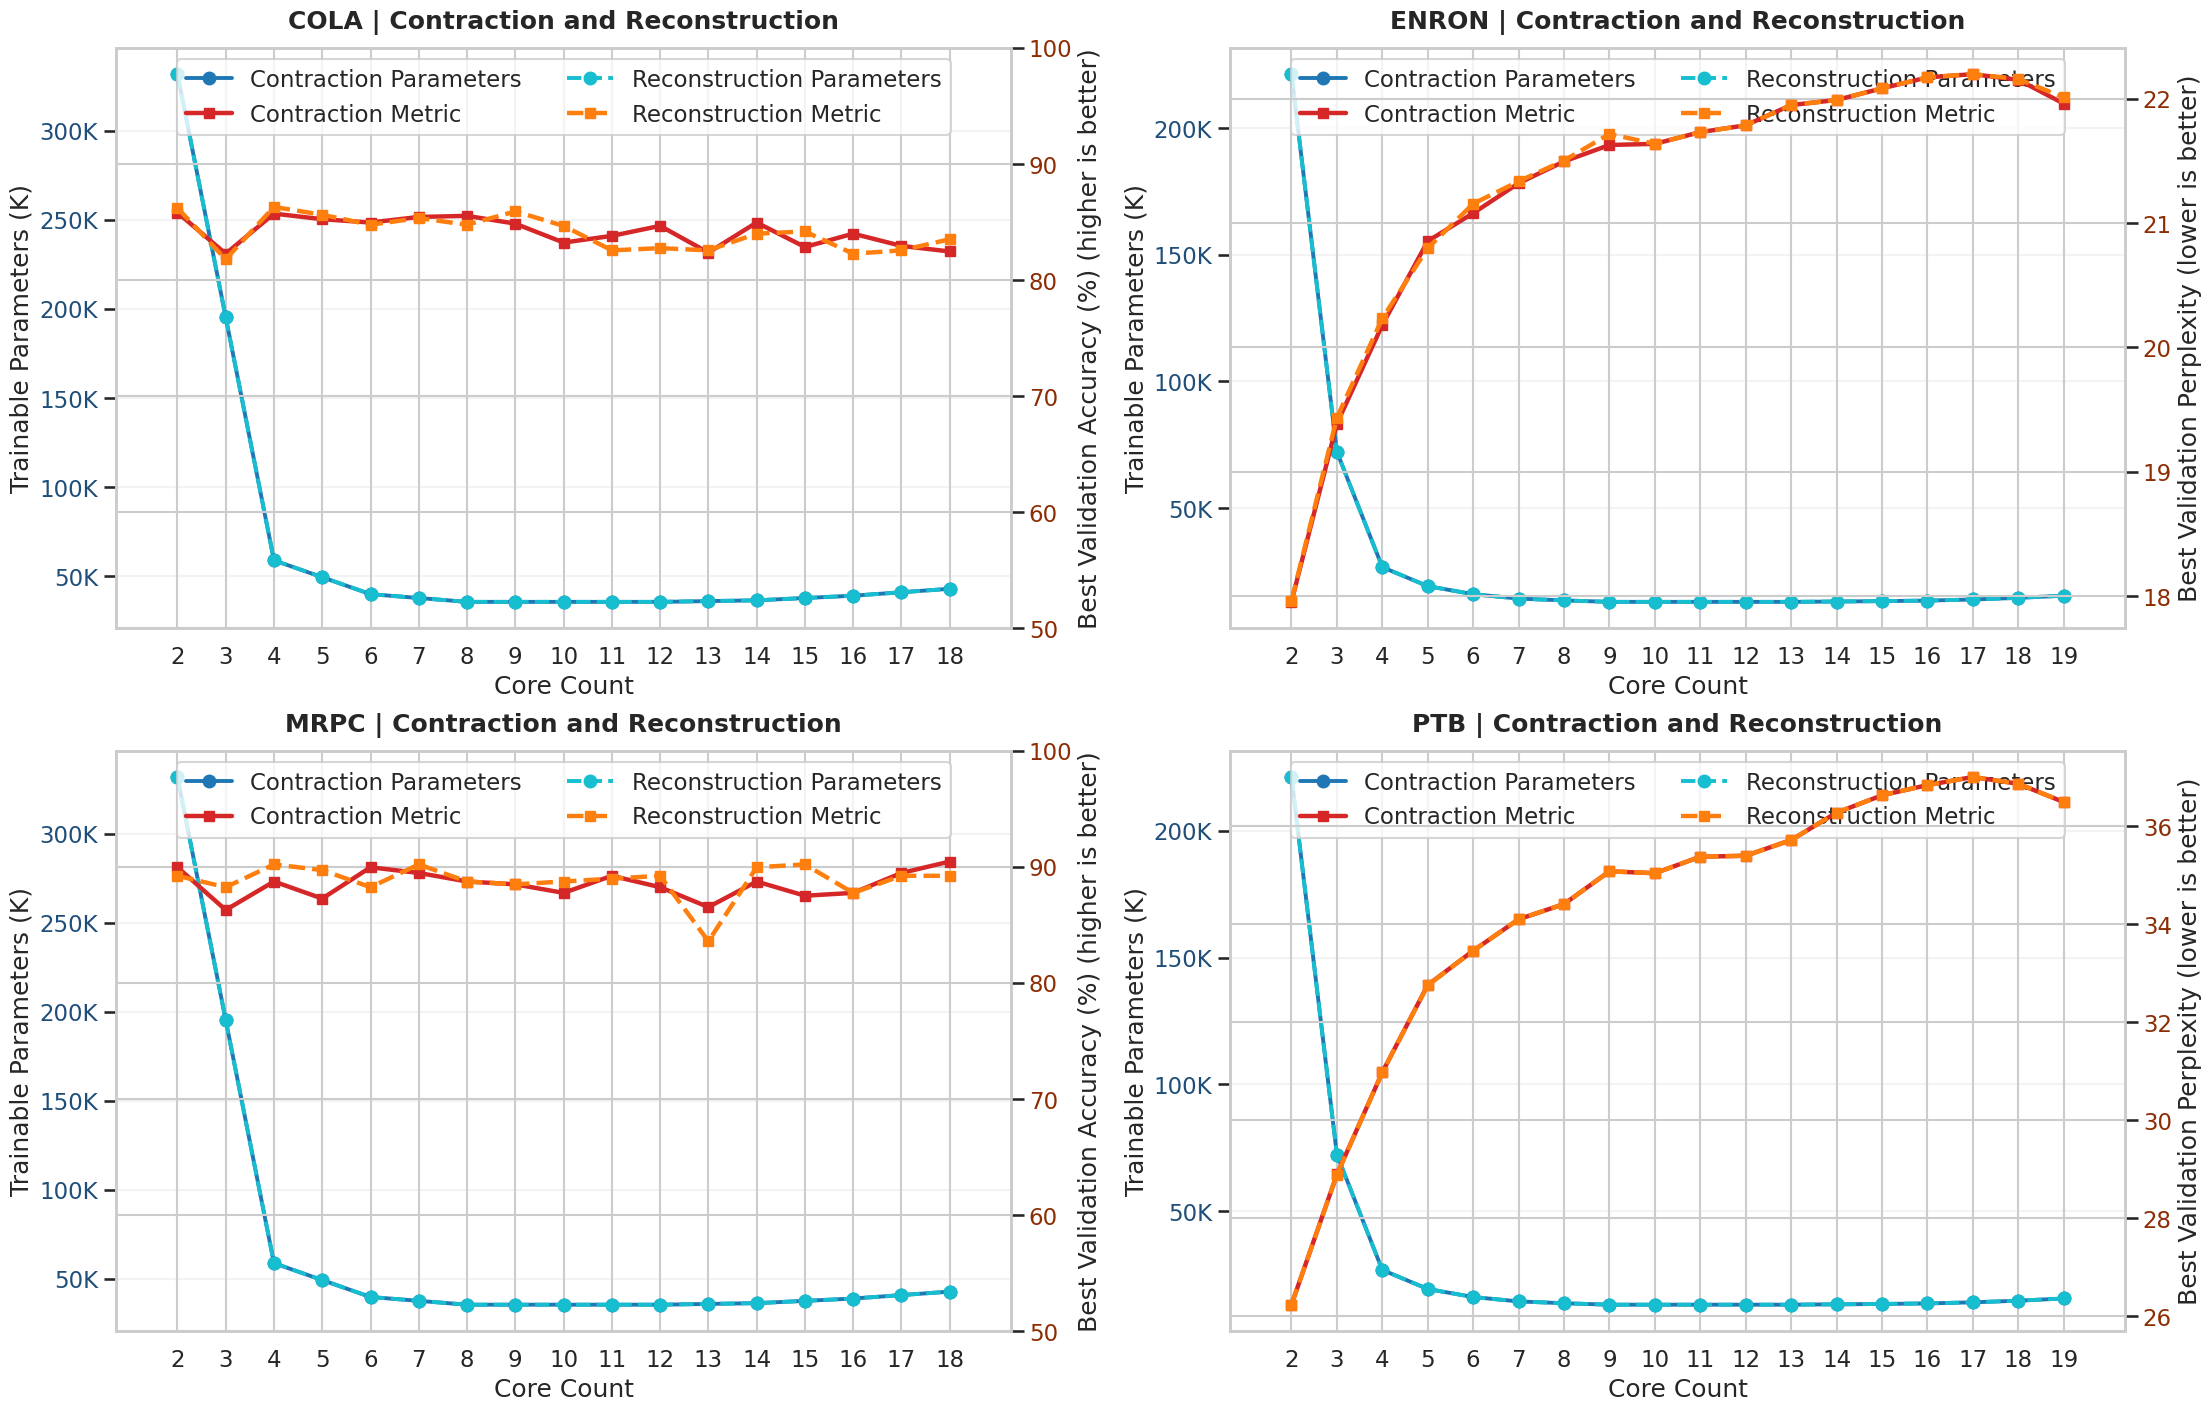

In [56]:
# Optional dataset filter. Leave as None to plot all datasets.
DATASET_FILTER = None          # e.g. 'mrpc', 'cola', 'ptb', 'enron'

plot_df = summary_df.copy()
if DATASET_FILTER is not None:
    plot_df = plot_df.loc[plot_df['dataset_name'] == DATASET_FILTER].copy()

if plot_df.empty:
    raise ValueError('Current filters produced an empty dataframe.')

plot_dataset_grid(plot_df)
